# Course 2: Advanced Learning Algorithms

## Complete Summary with Theory and Practice

This comprehensive notebook summarizes all key concepts from Course 2 of the Machine Learning Specialization, covering neural networks, deep learning with TensorFlow, practical advice for machine learning, and decision trees.

---

## Table of Contents
1. [Neural Networks Fundamentals](#nn-fundamentals)
2. [Neural Network Implementation](#nn-implementation)
3. [TensorFlow and Keras](#tensorflow)
4. [Activation Functions](#activations)
5. [Multiclass Classification](#multiclass)
6. [Advanced Optimization](#optimization)
7. [Advice for Applying Machine Learning](#advice)
8. [Bias and Variance](#bias-variance)
9. [Machine Learning Development Process](#ml-process)
10. [Decision Trees](#decision-trees)
11. [Tree Ensembles](#ensembles)

---

<a name="nn-fundamentals"></a>
## 1. Neural Networks Fundamentals

### What is a Neural Network?

A neural network is a machine learning model inspired by the human brain. It consists of layers of interconnected "neurons" that process information.

**Why Neural Networks?**
- Can learn extremely complex, non-linear patterns
- Automatically discover features from raw data
- State-of-the-art performance in many domains (computer vision, NLP, speech)
- Scalable to large datasets

### Biological Motivation

Human brain: ~86 billion neurons, each connected to thousands of others
- Neurons receive electrical signals through dendrites
- Process signals in cell body
- Send output through axon to other neurons

Artificial neural networks simplify this concept but capture the core idea of connected processing units.

### Neural Network Architecture

**Components:**
1. **Input Layer**: receives the features $\mathbf{x}$
2. **Hidden Layers**: intermediate layers that transform inputs
3. **Output Layer**: produces the final prediction $\hat{y}$

**Notation:**
- $L$ = total number of layers
- $n^{[l]}$ = number of units in layer $l$
- $a^{[l]}$ = activations (outputs) of layer $l$
- $a^{[l]}_j$ = activation of unit $j$ in layer $l$
- $\mathbf{w}^{[l]}$, $b^{[l]}$ = parameters for layer $l$

### Example: Simple Neural Network

```
Input Layer (x)  →  Hidden Layer  →  Output Layer (ŷ)
  x1                   a1[1]              a[2]
  x2         →        a2[1]         →     
  x3                   a3[1]              
```

**Architecture:**
- Input layer: 3 features $(x_1, x_2, x_3)$
- Hidden layer (Layer 1): 3 units
- Output layer (Layer 2): 1 unit

### Forward Propagation

**Forward propagation** is the process of computing outputs layer by layer.

**For each layer $l$:**

1. Compute weighted sum: 
$$z^{[l]} = \mathbf{W}^{[l]} a^{[l-1]} + \mathbf{b}^{[l]}$$

2. Apply activation function:
$$a^{[l]} = g^{[l]}(z^{[l]})$$

Where:
- $\mathbf{W}^{[l]}$ is the weight matrix for layer $l$
- $\mathbf{b}^{[l]}$ is the bias vector for layer $l$
- $g^{[l]}$ is the activation function for layer $l$
- $a^{[0]} = \mathbf{x}$ (input features)

**Example for one unit:**

For unit $j$ in layer $l$:
$$a^{[l]}_j = g\left(\mathbf{w}^{[l]}_j \cdot \mathbf{a}^{[l-1]} + b^{[l]}_j\right)$$

### Layer Types

1. **Dense (Fully Connected) Layer**: Every neuron connects to all neurons in previous layer
2. **Input Layer**: Not counted as a "layer" (just the features)
3. **Hidden Layers**: All layers between input and output
4. **Output Layer**: Final layer that produces predictions

### Why Multiple Layers?

Each layer learns different levels of abstraction:

**Example: Face Recognition**
- Layer 1: Detects edges
- Layer 2: Detects facial features (eyes, nose, mouth)
- Layer 3: Detects faces
- Layer 4: Identifies specific people

**Deep Learning** = Neural networks with many hidden layers (deep networks)

XOR Dataset:
X: [[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [[0 1 1 0]]

Neural Network Architecture:
Input features: 2
Hidden layer 1: 4 units
Hidden layer 2: 4 units
Output layer: 1 unit(s)

Parameter Shapes:
W1: (4, 2)
b1: (4, 1)
W2: (4, 4)
b2: (4, 1)
W3: (1, 4)
b3: (1, 1)

Output shape: (1, 4)
Output values (before training):
[[0.5       ]
 [0.46813439]
 [0.5       ]
 [0.5       ]]


C:\Users\Javad\AppData\Local\Temp\ipykernel_20600\3722579657.py:126: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_train[i, 0], X_train[i, 1], c=colors[i],


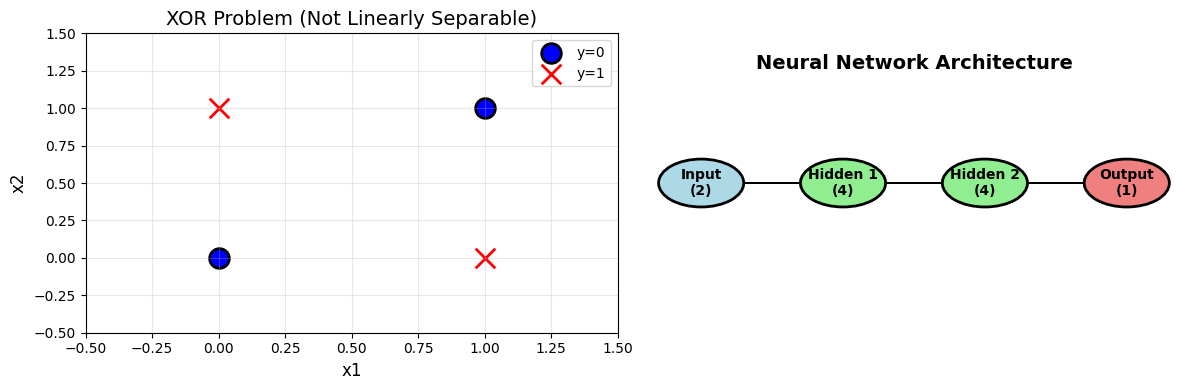


NOTE: XOR problem cannot be solved with linear models!
Neural networks can learn this non-linear decision boundary.


In [1]:
### Code Example: Neural Network from Scratch

import numpy as np
import matplotlib.pyplot as plt

# Activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

# Simple neural network class
class SimpleNeuralNetwork:
    def __init__(self, layer_dims):
        """
        layer_dims: list containing dimensions of each layer
        Example: [3, 4, 4, 1] means:
            - Input: 3 features
            - Hidden layer 1: 4 units
            - Hidden layer 2: 4 units
            - Output: 1 unit
        """
        self.layer_dims = layer_dims
        self.parameters = self.initialize_parameters()
    
    def initialize_parameters(self):
        """
        Initialize weights and biases for each layer
        """
        np.random.seed(42)
        parameters = {}
        L = len(self.layer_dims)
        
        for l in range(1, L):
            # He initialization (good for ReLU)
            parameters[f'W{l}'] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * np.sqrt(2. / self.layer_dims[l-1])
            parameters[f'b{l}'] = np.zeros((self.layer_dims[l], 1))
        
        return parameters
    
    def forward_propagation(self, X, activation='sigmoid'):
        """
        Forward propagation through the network
        """
        caches = []
        A = X.T  # Shape: (n_features, m_examples)
        L = len(self.layer_dims) - 1
        
        # Hidden layers (use ReLU)
        for l in range(1, L):
            A_prev = A
            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']
            
            Z = np.dot(W, A_prev) + b
            A = relu(Z)
            
            cache = (A_prev, W, b, Z)
            caches.append(cache)
        
        # Output layer (use sigmoid for binary classification)
        W = self.parameters[f'W{L}']
        b = self.parameters[f'b{L}']
        Z = np.dot(W, A) + b
        
        if activation == 'sigmoid':
            A = sigmoid(Z)
        else:
            A = Z  # Linear for regression
        
        cache = (A, W, b, Z)
        caches.append(cache)
        
        return A, caches
    
    def predict(self, X):
        """
        Make predictions
        """
        A, _ = self.forward_propagation(X, activation='sigmoid')
        predictions = (A > 0.5).astype(int)
        return predictions.T

# Example dataset (XOR problem - not linearly separable!)
np.random.seed(1)

# XOR Dataset
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([[0], [1], [1], [0]])  # XOR output

print("XOR Dataset:")
print("X:", X_train)
print("y:", y_train.T)

# Create and initialize network
# Architecture: 2 inputs -> 4 hidden units -> 4 hidden units -> 1 output
nn = SimpleNeuralNetwork([2, 4, 4, 1])

print(f"\nNeural Network Architecture:")
print(f"Input features: {nn.layer_dims[0]}")
for i in range(1, len(nn.layer_dims) - 1):
    print(f"Hidden layer {i}: {nn.layer_dims[i]} units")
print(f"Output layer: {nn.layer_dims[-1]} unit(s)")

# Check shapes of parameters
print(f"\nParameter Shapes:")
for key, value in nn.parameters.items():
    print(f"{key}: {value.shape}")

# Forward propagation
A_output, caches = nn.forward_propagation(X_train, activation='sigmoid')
print(f"\nOutput shape: {A_output.shape}")
print(f"Output values (before training):")
print(A_output.T)

# Visualize XOR problem
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: XOR Dataset
ax = axes[0]
colors = ['blue' if y == 0 else 'red' for y in y_train.flatten()]
markers = ['o' if y == 0 else 'x' for y in y_train.flatten()]

for i in range(len(X_train)):
    ax.scatter(X_train[i, 0], X_train[i, 1], c=colors[i], 
              marker=markers[i], s=200, edgecolors='black', linewidth=2)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('XOR Problem (Not Linearly Separable)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(['y=0', 'y=1'])

# Plot 2: Network Architecture Visualization
ax = axes[1]
ax.text(0.5, 0.9, 'Neural Network Architecture', 
        ha='center', va='center', fontsize=14, weight='bold')

layers = ['Input\n(2)', 'Hidden 1\n(4)', 'Hidden 2\n(4)', 'Output\n(1)']
y_pos = [0.5] * len(layers)
x_pos = np.linspace(0.1, 0.9, len(layers))

for i, (x, y, label) in enumerate(zip(x_pos, y_pos, layers)):
    if i == 0:
        color = 'lightblue'
    elif i == len(layers) - 1:
        color = 'lightcoral'
    else:
        color = 'lightgreen'
    
    circle = plt.Circle((x, y), 0.08, color=color, ec='black', linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, weight='bold')
    
    # Draw arrows
    if i < len(layers) - 1:
        ax.arrow(x + 0.08, y, x_pos[i+1] - x - 0.16, 0, 
                head_width=0.03, head_length=0.02, fc='black', ec='black')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("NOTE: XOR problem cannot be solved with linear models!")
print("Neural networks can learn this non-linear decision boundary.")
print("="*60)

<a name="tensorflow"></a>
## 2. TensorFlow and Keras

### What is TensorFlow?

**TensorFlow** is an open-source machine learning framework developed by Google. **Keras** is a high-level API integrated into TensorFlow that makes building neural networks simple and intuitive.

**Why use TensorFlow/Keras?**
- Automatic differentiation (computes gradients for you!)
- GPU acceleration
- Production-ready deployment
- Large ecosystem and community
- Easy to use API

### Building Models in TensorFlow

**Three main steps:**
1. **Define the model** (specify architecture)
2. **Compile the model** (choose loss function and optimizer)
3. **Fit the model** (train on data)

### Model Architecture with Sequential API

**Sequential API**: Build model layer by layer

```python
model = Sequential([
    Dense(units=25, activation='relu'),
    Dense(units=15, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
```

**Dense Layer**: Fully connected layer
- `units`: number of neurons in the layer
- `activation`: activation function (relu, sigmoid, tanh, etc.)

### Compiling the Model

```python
model.compile(
    loss='binary_crossentropy',  # or BinaryCrossentropy()
    optimizer='adam'              # adaptive learning rate
)
```

**Common loss functions:**
- `binary_crossentropy`: Binary classification
- `sparse_categorical_crossentropy`: Multiclass (labels as integers)
- `categorical_crossentropy`: Multiclass (labels as one-hot vectors)
- `mean_squared_error`: Regression

**Common optimizers:**
- `'adam'`: Adaptive learning rate (most popular)
- `'sgd'`: Stochastic gradient descent
- `'rmsprop'`: Root mean square propagation

### Training the Model

```python
model.fit(X_train, y_train, epochs=100)
```

- `epochs`: Number of complete passes through training data
- TensorFlow automatically does:
  - Forward propagation
  - Cost computation
  - Backpropagation
  - Parameter updates

### Making Predictions

```python
predictions = model.predict(X_new)
```

For binary classification:
```python
y_pred = (predictions >= 0.5).astype(int)
```

### Model Layers in Detail

**Input Layer** (optional but recommended for clarity):
```python
tf.keras.Input(shape=(n_features,))
```

**Hidden Layers:**
```python
Dense(units=n_units, activation='relu')
```

**Output Layer:**
- Binary classification: `Dense(1, activation='sigmoid')`
- Multiclass: `Dense(n_classes, activation='softmax')`
- Regression: `Dense(1, activation='linear')` or `Dense(1)`

TensorFlow version: 2.19.0
Training set: (800, 2)
Test set: (200, 2)


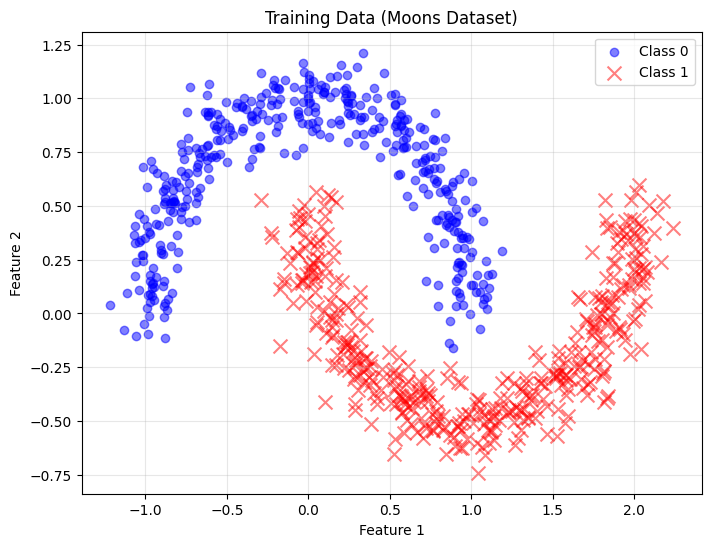


METHOD 1: Sequential API


Model: "model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)


Training Accuracy: 100.00%
Test Accuracy: 100.00%

METHOD 2: Building layer by layer
Model built successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Predictions (probabilities): [1.0000000e+00 1.7930432e-05 1.0000000e+00 2.4134151e-06 1.0000000e+00]
True labels: [1 0 1 0 1]


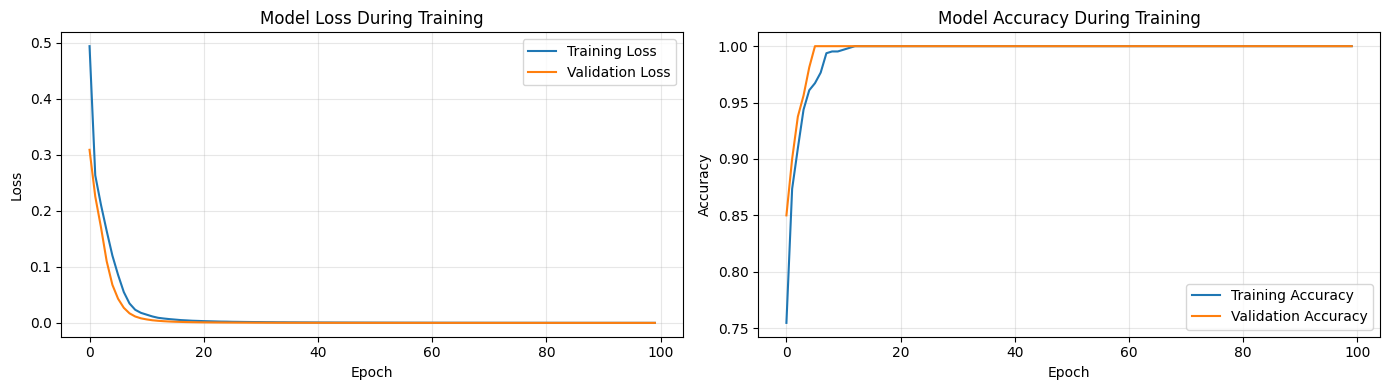

1018/1018 ━━━━━━━━━━━━━━━━━━━━ 1s 521us/step


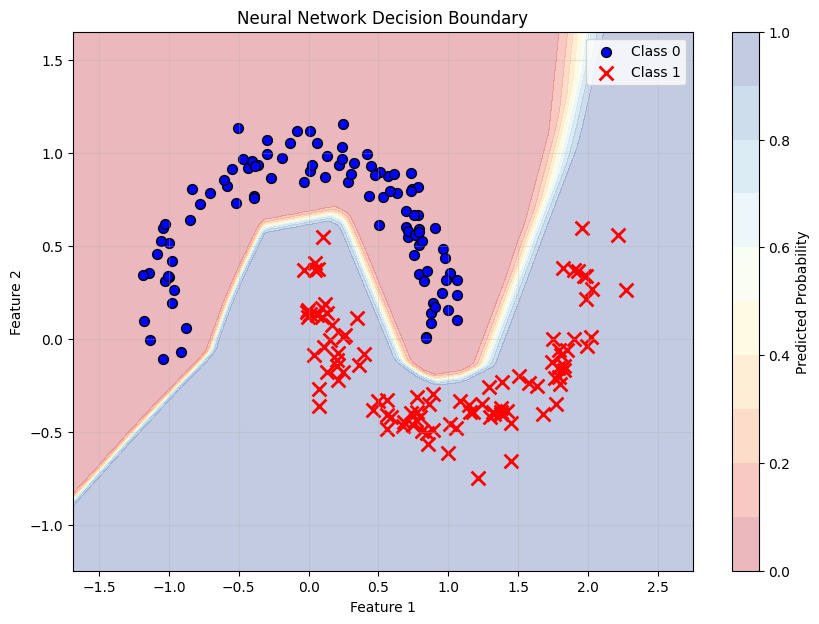


MODEL PARAMETERS

Layer: L1
  Weights shape: (2, 25)
  Bias shape: (25,)
  Total parameters: 75

Layer: L2
  Weights shape: (25, 15)
  Bias shape: (15,)
  Total parameters: 390

Layer: L3
  Weights shape: (15, 1)
  Bias shape: (1,)
  Total parameters: 16


In [2]:
### Code Example: Building Neural Networks with TensorFlow

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Generate synthetic dataset for binary classification
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Visualize dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train==0][:, 0], X_train[y_train==0][:, 1], 
           c='blue', marker='o', label='Class 0', alpha=0.5)
plt.scatter(X_train[y_train==1][:, 0], X_train[y_train==1][:, 1], 
           c='red', marker='x', s=100, label='Class 1', alpha=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data (Moons Dataset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Method 1: Sequential API (most common)
print("\n" + "="*60)
print("METHOD 1: Sequential API")
print("="*60)

model1 = Sequential([
    Input(shape=(2,)),          # Input layer (2 features)
    Dense(25, activation='relu', name='L1'),   # Hidden layer 1
    Dense(15, activation='relu', name='L2'),   # Hidden layer 2
    Dense(1, activation='sigmoid', name='L3')  # Output layer
], name='model1')

# Display model architecture
model1.summary()

# Compile the model
model1.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# Train the model
history1 = model1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0  # Set to 1 to see training progress
)

# Evaluate the model
train_loss, train_acc = model1.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model1.evaluate(X_test, y_test, verbose=0)

print(f"\nTraining Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Method 2: Adding layers one by one
print("\n" + "="*60)
print("METHOD 2: Building layer by layer")
print("="*60)

model2 = Sequential(name='model2')
model2.add(Input(shape=(2,)))
model2.add(Dense(25, activation='relu'))
model2.add(Dense(15, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model built successfully!")

# Make predictions
predictions = model1.predict(X_test[:5])
print(f"\nPredictions (probabilities): {predictions.flatten()}")
print(f"True labels: {y_test[:5]}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Loss
axes[0].plot(history1.history['loss'], label='Training Loss')
axes[0].plot(history1.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss During Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(history1.history['accuracy'], label='Training Accuracy')
axes[1].plot(history1.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy During Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize decision boundary
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    h = 0.02  # step size in mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, levels=np.linspace(0, 1, 11), cmap='RdYlBu')
    plt.colorbar(label='Predicted Probability')
    
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], c='blue', marker='o', 
               edgecolors='black', label='Class 0', s=50)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='red', marker='x', 
               s=100, label='Class 1', linewidths=2)
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(model1, X_test, y_test, "Neural Network Decision Boundary")

# Extracting weights and biases
print("\n" + "="*60)
print("MODEL PARAMETERS")
print("="*60)

for layer in model1.layers:
    if len(layer.get_weights()) > 0:
        W, b = layer.get_weights()
        print(f"\nLayer: {layer.name}")
        print(f"  Weights shape: {W.shape}")
        print(f"  Bias shape: {b.shape}")
        print(f"  Total parameters: {W.size + b.size}")

<a name="activations"></a>
## 3. Activation Functions

### Why Activation Functions?

Without activation functions, neural networks would just be linear transformations, equivalent to linear regression! Activation functions introduce **non-linearity**, enabling networks to learn complex patterns.

### Common Activation Functions

#### 1. **ReLU (Rectified Linear Unit)** - Most Popular!

$$g(z) = \max(0, z) = \begin{cases} z & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

**Advantages:**
- Fast to compute
- Helps avoid vanishing gradient problem
- Most commonly used in hidden layers

**Disadvantages:**
- "Dying ReLU" problem (neurons can become inactive)

#### 2. **Sigmoid (Logistic Function)**

$$g(z) = \frac{1}{1 + e^{-z}}$$

**Properties:**
- Output range: $(0, 1)$
- Smooth gradient

**Use cases:**
- **Output layer** for binary classification
- Rarely used in hidden layers (vanishing gradient)

#### 3. **Tanh (Hyperbolic Tangent)**

$$g(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

**Properties:**
- Output range: $(-1, 1)$
- Zero-centered (better than sigmoid)

**Use cases:**
- Sometimes used in hidden layers
- Better than sigmoid for hidden layers but worse than ReLU

#### 4. **Linear Activation**

$$g(z) = z$$

**Use cases:**
- **Output layer** for regression problems only
- Never use in hidden layers! (defeats purpose of neural network)

#### 5. **Softmax** (for multiclass)

$$a_j = \frac{e^{z_j}}{\sum_{k=1}^{N} e^{z_k}}$$

**Properties:**
- Outputs sum to 1 (can interpret as probabilities)
- Used only in output layer

**Use cases:**
- **Output layer** for multiclass classification

### Choosing Activation Functions

**Best Practices:**

| Layer Type | Task | Recommended Activation |
|------------|------|----------------------|
| Hidden layers | Any | **ReLU** (start here!) |
| Output layer | Binary classification | **Sigmoid** |
| Output layer | Multiclass classification | **Softmax** |
| Output layer | Regression | **Linear** (or none) |

**Advanced variants:**
- **Leaky ReLU**: $g(z) = \max(0.01z, z)$ (solves dying ReLU)
- **ELU**: Exponential Linear Unit
- **Swish**: $g(z) = z \cdot \sigma(z)$ (used in some modern architectures)

<a name="multiclass"></a>
## 4. Multiclass Classification

### From Binary to Multiclass

**Binary**: 2 classes (0 or 1)
**Multiclass**: More than 2 classes (e.g., digits 0-9, cat/dog/bird)

### Softmax Regression

Extension of logistic regression to multiple classes.

**Output layer with softmax:**

For class $j$ out of $N$ classes:
$$a_j = \frac{e^{z_j}}{\sum_{k=1}^{N} e^{z_k}}$$

**Properties:**
- All outputs are positive
- All outputs sum to 1: $\sum_{j=1}^{N} a_j = 1$
- Can interpret as probabilities: $P(y=j|\mathbf{x})$

**Example:** 4 classes

If $z = [5, 2, -1, 3]$:
$$a_1 = \frac{e^5}{e^5 + e^2 + e^{-1} + e^3} \approx 0.842$$
$$a_2 = \frac{e^2}{e^5 + e^2 + e^{-1} + e^3} \approx 0.042$$
$$a_3 = \frac{e^{-1}}{e^5 + e^2 + e^{-1} + e^3} \approx 0.002$$
$$a_4 = \frac{e^3}{e^5 + e^2 + e^{-1} + e^3} \approx 0.114$$

Sum = 1.0 ✓

### Softmax Cost Function (Categorical Cross-Entropy)

**Loss for sparse labels** (y is class index):
$$J(\mathbf{w}, b) = -\frac{1}{m}\sum_{i=1}^{m} \log(a_{y^{(i)}}^{(i)})$$

**Loss for one-hot encoded labels:**
$$J(\mathbf{w}, b) = -\frac{1}{m}\sum_{i=1}^{m}\sum_{j=1}^{N} y_j^{(i)} \log(a_j^{(i)})$$

Where $y_j^{(i)} = 1$ if example $i$ belongs to class $j$, else 0.

### Neural Network for Multiclass

**Architecture:**
```
Input → Hidden Layers (ReLU) → Output Layer (Softmax)
```

**TensorFlow implementation:**
```python
model = Sequential([
    Dense(25, activation='relu'),
    Dense(15, activation='relu'),
    Dense(num_classes, activation='softmax')  # num_classes units
])

model.compile(
    loss='sparse_categorical_crossentropy',  # if labels are integers
    # OR
    loss='categorical_crossentropy',  # if labels are one-hot
    optimizer='adam'
)
```

### Important: Numerical Stability

**Problem**: Computing softmax then taking log can be numerically unstable.

**Solution**: Use `from_logits=True` in loss function!

**Better implementation:**
```python
model = Sequential([
    Dense(25, activation='relu'),
    Dense(15, activation='relu'),
    Dense(num_classes)  # NO activation here!
])

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam'
)
```

TensorFlow combines softmax and cross-entropy computation for better numerical precision.

**For predictions:**
```python
logits = model.predict(X)
probabilities = tf.nn.softmax(logits)
predicted_class = np.argmax(probabilities, axis=1)
```

<a name="activations"></a>
## 3. Activation Functions

### Why Activation Functions?

Without activation functions, a neural network would just be a linear transformation, no matter how many layers! Activation functions introduce **non-linearity**, allowing networks to learn complex patterns.

### Common Activation Functions

**1. Sigmoid: $g(z) = \frac{1}{1 + e^{-z}}$**

- **Range**: (0, 1)
- **Use case**: Output layer for binary classification
- **Pros**: Outputs interpretable probabilities
- **Cons**: Vanishing gradients, slow training
- **Derivative**: $g'(z) = g(z)(1 - g(z))$

**2. ReLU (Rectified Linear Unit): $g(z) = \max(0, z)$**

- **Range**: [0, ∞)
- **Use case**: Hidden layers (most popular!)
- **Pros**: Fast to compute, helps avoid vanishing gradients
- **Cons**: "Dying ReLU" problem (neurons can get stuck at 0)
- **Derivative**: $g'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$

**3. Tanh (Hyperbolic Tangent): $g(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$**

- **Range**: (-1, 1)  
- **Use case**: Hidden layers (less common than ReLU)
- **Pros**: Zero-centered (easier optimization)
- **Cons**: Vanishing gradients
- **Derivative**: $g'(z) = 1 - g(z)^2$

**4. Linear: $g(z) = z$**

- **Range**: (-∞, ∞)
- **Use case**: Output layer for regression
- **Pros**: Simple
- **Cons**: No non-linearity

**5. Softmax**: (for multiclass classification)

$$g(z)_j = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}$$

- **Range**: (0, 1) with $\sum_j g(z)_j = 1$
- **Use case**: Output layer for multiclass classification
- **Pros**: Outputs probability distribution

### Choosing Activation Functions

**General guidelines:**

- **Hidden layers**: Use **ReLU** (most common and effective)
- **Output layer**:
  - Binary classification: **sigmoid**
  - Multiclass classification: **softmax**
  - Regression: **linear** (or no activation)

**Why ReLU is popular:**
1. Computationally efficient
2. Doesn't saturate (no vanishing gradient for positive values)
3. Encourages sparse activation (many neurons output 0)
4. Works well in practice for most applications

<a name="multiclass"></a>
## 4. Multiclass Classification

### Softmax Regression

**Multiclass classification**: Predicting one of K classes (K > 2)

Examples:
- Digit recognition: 0, 1, 2, ..., 9 (10 classes)
- Image classification: cat, dog, bird, ... (K classes)

**Softmax function** computes probabilities for each class:

$$a_j = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}} \quad \text{for } j = 1, ..., K$$

Where:
- $z_j$ is the logit (raw output) for class $j$
- $a_j$ is the probability of class $j$
- $\sum_{j=1}^{K} a_j = 1$ (probabilities sum to 1)

### Neural Network for Multiclass

**Architecture:**
- Output layer: K units (one per class)
- Activation: softmax
- Output: probability distribution over K classes

```python
model = Sequential([
    Dense(25, activation='relu'),
    Dense(15, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes
])
```

### Cost Function: Categorical Cross-Entropy

**Sparse categorical cross-entropy** (labels are integers 0, 1, ..., K-1):

$$J(\mathbf{w},b) = -\frac{1}{m}\sum_{i=1}^{m}\log(a_{y^{(i)}}^{(i)})$$

Where $a_{y^{(i)}}^{(i)}$ is the predicted probability for the true class.

**Categorical cross-entropy** (labels are one-hot encoded):

$$J(\mathbf{w},b) =-\frac{1}{m}\sum_{i=1}^{m}\sum_{j=1}^{K}y_j^{(i)}\log(a_j^{(i)})$$

### Important: Numerical Stability

**Problem**: Computing softmax then log can cause numerical issues.

**Solution**: TensorFlow can combine softmax and cross-entropy for better numerical stability:

```python
# RECOMMENDED (more numerically stable)
model = Sequential([
    Dense(25, activation='relu'),
    Dense(15, activation='relu'),
    Dense(10)  # No activation! Linear output
])

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)
```

Setting `from_logits=True` tells TensorFlow the output is logits (before softmax), so it applies softmax internally in a numerically stable way.

To make predictions:
```python
logits = model.predict(X)
predictions = tf.nn.softmax(logits)  # Apply softmax to get probabilities
y_pred = np.argmax(predictions, axis=1)  # Get class with highest probability
```

Number of classes: 4
Training samples: 800
Test samples: 200


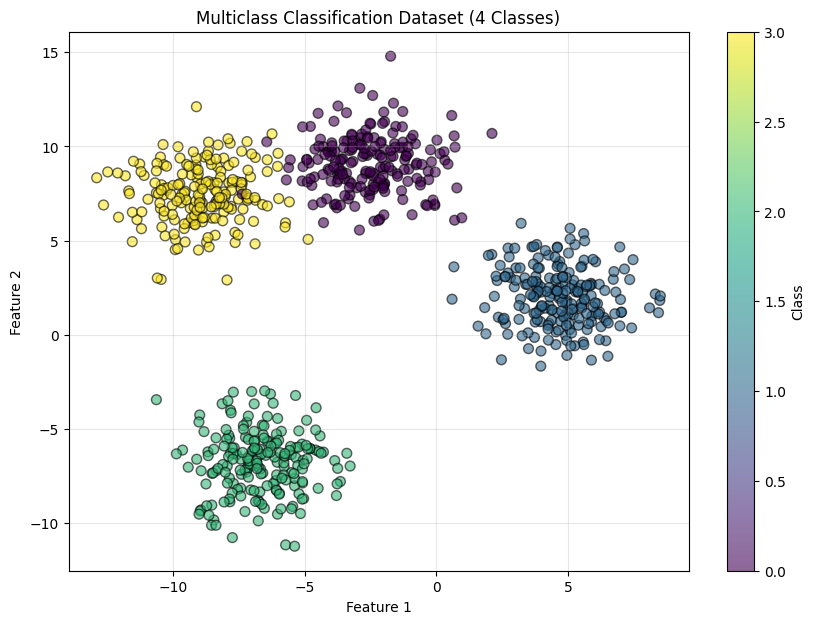

c:\Users\Javad\.pyenv\pyenv-win\versions\3.12.5\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "multiclass_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529 (2.07 KB)

 Trainable params: 529 (2.07 KB)

 Non-trainable params: 0 (0.00 B)


Training Accuracy: 99.50%
Test Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Sample Predictions:
Logits (raw output):
[[-13.983717   13.257904   -6.6902742 -36.34355  ]
 [ -2.690825  -10.522614   -8.626627    3.168125 ]
 [-40.47753     0.7121237  29.364838  -23.91065  ]
 [-15.545412   12.835869   -4.087251  -29.688818 ]
 [  9.648923  -10.853625  -20.445635  -13.694956 ]]

Probabilities (after softmax):
[[1.4760951e-12 1.0000000e+00 2.1707842e-09 2.8731713e-22]
 [2.8460920e-03 1.1296559e-06 7.5225080e-06 9.9714524e-01]
 [4.6541940e-31 3.5998510e-13 1.0000000e+00 7.2903567e-24]
 [4.7224383e-13 1.0000000e+00 4.4707679e-08 3.4022197e-19]
 [1.0000000e+00 1.2469713e-09 8.5133249e-14 7.2758188e-11]]

Predicted classes: [1 3 2 1 0]
True classes: [1 3 2 1 0]

Probability sums: [1. 1. 1. 1. 1.]


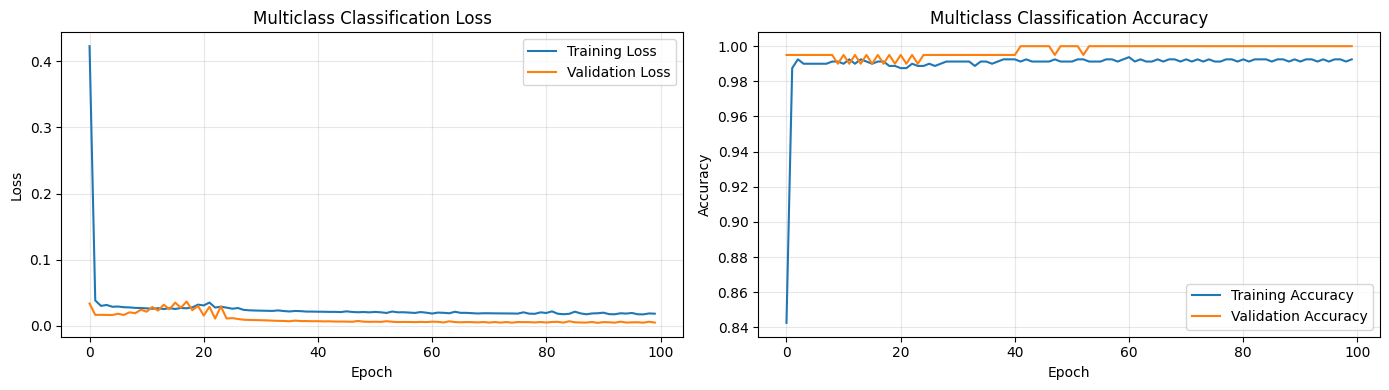

40671/40671 ━━━━━━━━━━━━━━━━━━━━ 20s 488us/step


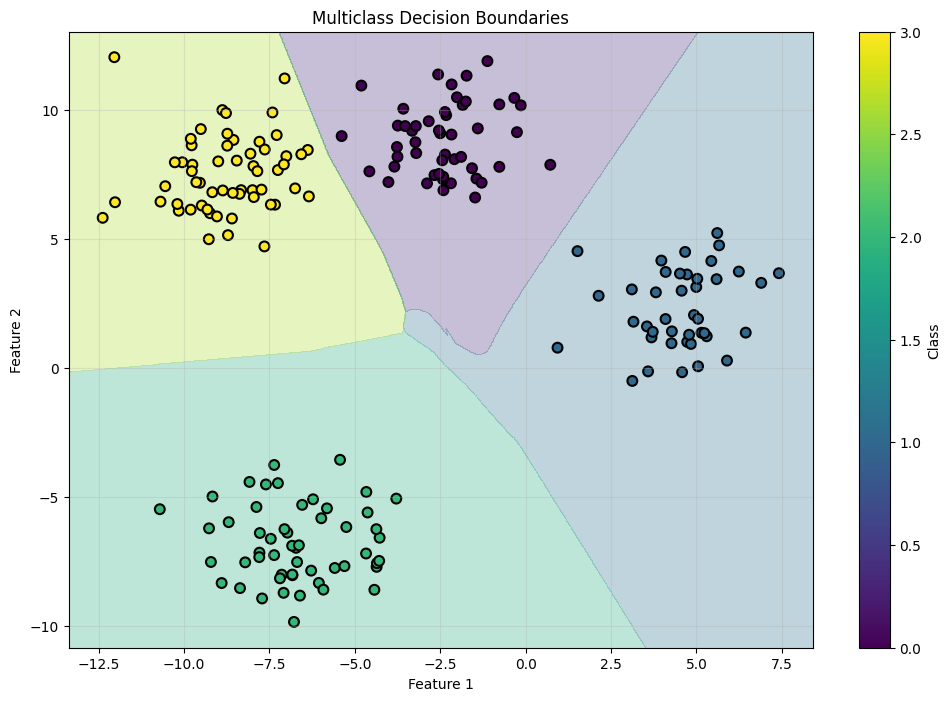


Alternative: Model with softmax activation (less stable)
Model with softmax activation created (use for inference, not training)


In [3]:
### Code Example: Multiclass Classification with TensorFlow

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Generate multiclass dataset
np.random.seed(42)
tf.random.set_seed(42)

X, y = make_blobs(n_samples=1000, centers=4, n_features=2, 
                  cluster_std=1.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Number of classes: {len(np.unique(y))}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Visualize dataset
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                     cmap='viridis', s=50, alpha=0.6, edgecolors='black')
plt.colorbar(scatter, label='Class')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Multiclass Classification Dataset (4 Classes)')
plt.grid(True, alpha=0.3)
plt.show()

# Build model with numerically stable implementation
model = Sequential([
    Dense(25, activation='relu', input_shape=(2,)),
    Dense(15, activation='relu'),
    Dense(4)  # 4 classes, NO softmax here (will use from_logits=True)
], name='multiclass_model')

model.summary()

# Compile with numerically stable loss
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

# Evaluate
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTraining Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Make predictions
logits = model.predict(X_test[:5])
probabilities = tf.nn.softmax(logits)
predicted_classes = np.argmax(probabilities, axis=1)

print(f"\nSample Predictions:")
print(f"Logits (raw output):\n{logits}")
print(f"\nProbabilities (after softmax):\n{probabilities.numpy()}")
print(f"\nPredicted classes: {predicted_classes}")
print(f"True classes: {y_test[:5]}")

# Verify probabilities sum to 1
print(f"\nProbability sums: {np.sum(probabilities.numpy(), axis=1)}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Multiclass Classification Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Multiclass Classification Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize decision boundaries
def plot_multiclass_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    X_mesh = np.c_[xx.ravel(), yy.ravel()]
    logits = model.predict(X_mesh)
    Z = np.argmax(tf.nn.softmax(logits), axis=1)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=np.arange(5) - 0.5)
    
    # Plot training points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', 
                         s=50, edgecolors='black', linewidth=1.5)
    plt.colorbar(scatter, label='Class')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Multiclass Decision Boundaries')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_multiclass_decision_boundary(model, X_test, y_test)

# Alternative: Model with softmax in output (less numerically stable)
print("\n" + "="*60)
print("Alternative: Model with softmax activation (less stable)")
print("="*60)

model_alt = Sequential([
    Dense(25, activation='relu', input_shape=(2,)),
    Dense(15, activation='relu'),
    Dense(4, activation='softmax')  # Softmax in the model
], name='multiclass_model_alt')

model_alt.compile(
    loss='sparse_categorical_crossentropy',  # from_logits=False by default
    optimizer='adam',
    metrics=['accuracy']
)

print("Model with softmax activation created (use for inference, not training)")

<a name="advice"></a>
## 5. Advice for Applying Machine Learning

### Model Evaluation

**Problem**: Training error alone doesn't tell you how well your model will perform on new data!

**Solution**: Split data into training and test sets

```python
# Typical split: 70-80% train, 20-30% test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
```

**Evaluation metrics:**
- **Classification**: Accuracy, Precision, Recall, F1-score
- **Regression**: MSE, RMSE, MAE, R²

### Model Selection and Training/Validation/Test  Sets

**Problem**: How to choose hyperparameters (λ, model complexity, etc.)?

**Solution**: Use 3-way split

1. **Training set** (60%): Train model parameters
2. **Validation set (Dev set)** (20%): Tune hyperparameters
3. **Test set** (20%): Final evaluation (use only once!)

**Process:**
1. Train multiple models on training set
2. Evaluate on validation set
3. Choose best model
4. Report final performance on test set

**Never use test set for tuning!** It will give overly optimistic estimates.

<a name="bias-variance"></a>
## 6. Bias and Variance

### Understanding Bias and Variance

**High Bias (Underfitting)**:
- Model is too simple
- Poor performance on training set AND test set
- $J_{train}$ is high, $J_{cv}$ is high
- $J_{train} \approx J_{cv}$

**High Variance (Overfitting)**:
- Model is too complex
- Great on training, poor on test
- $J_{train}$ is low, $J_{cv}$ is much higher
- Large gap: $J_{cv} \gg J_{train}$

**Just Right**:
- $J_{train}$ is low
- $J_{cv}$ is low
- $J_{cv} \approx J_{train}$

### Diagnosing Bias vs Variance

Plot learning curves: training error and validation error vs model complexity

| Symptom | Diagnosis |
|---------|-----------|
| High $J_{train}$, High $J_{cv}$, $J_{train} \approx J_{cv}$ | High Bias |
| Low $J_{train}$, High $J_{cv}$, $J_{cv} \gg J_{train}$ | High Variance |

### Regularization and Bias/Variance

**Effect of λ (regularization parameter):**
- λ too large → High bias (underfitting)
- λ too small (or 0) → High variance (overfitting)
- λ just right → Good balance

**To choose λ:**
1. Try λ ∈ {0, 0.01, 0.02, 0.04, 0.08, ..., 10}
2. Train model for each λ
3. Compute $J_{cv}$ (validation error)
4. Pick λ with lowest $J_{cv}$

### Fixing High Bias vs High Variance

**If High Bias (Underfitting):**
- ✅ Get more features
- ✅ Add polynomial features
- ✅ Decrease λ (less regularization)
- ✅ Increase model complexity (more layers/units)
- ❌ Getting more training data won't help much!

**If High Variance (Overfitting):**
- ✅ Get more training data
- ✅ Reduce number of features (feature selection)
- ✅ Increase λ (more regularization)
- ✅ Early stopping
- ❌ Making model more complex makes it worse!

### Learning Curves

Plot $J_{train}$ and $J_{cv}$ vs training set size $m$

**High Bias:**
- Both errors plateau at high values
- More data doesn't help much
- $J_{train}$ and $J_{cv}$ are close

**High Variance:**
- Large gap between $J_{train}$ and $J_{cv}$
- More data helps (gap shrinks)
- $J_{train}$ stays low, $J_{cv}$ decreases with more data

### Neural Networks and Bias/Variance

**Large neural networks rarely have high bias** (if trained well)
- Can fit very complex patterns
- Main challenge: overfitting (high variance)

**Recipe for neural networks:**
1. Does it do well on training set? ($J_{train}$ low?)
   - If no → Bigger network or train longer
2. Does it do well on validation set? ($J_{cv}$ low?)
   - If no → More data or regularization

**Regularization for neural networks:**
- L2 regularization (weight decay)
- Dropout
- Data augmentation
- Early stopping

<a name="bias-variance"></a>
## 5. Bias and Variance (Diagnosing ML Models)

### The Problem: How to Improve Your Model?

When your model doesn't perform well, what should you try?
- Get more training data?
- Try smaller/larger set of features?
- Add polynomial features?
- Increase/decrease regularization?

**Machine learning diagnostic**: A test you run to gain insight into what is/isn't working with a learning algorithm.

### Evaluating Your Model

**Split your data:**
- **Training set** (60-80%): Train model parameters
- **Validation set** (10-20%): Tune hyperparameters, select model
- **Test set** (10-20%): Final evaluation (use only once!)

**Training procedure:**
1. Optimize parameters on training set
2. Evaluate on validation set
3. Select best model
4. Report final performance on test set

### Bias and Variance

**High Bias (Underfitting):**
- Model is too simple
- Doesn't fit training data well
- $J_{train}$ is high
- $J_{cv} \approx J_{train}$ (both high)

**High Variance (Overfitting):**
- Model is too complex
- Fits training data perfectly but fails on new data
- $J_{train}$ is low
- $J_{cv} \gg J_{train}$ (large gap)

**Just Right:**
- $J_{train}$ is low
- $J_{cv}$ is low
- $J_{cv} \approx J_{train}$

### Diagnosing Bias vs Variance

Plot learning curves: Error vs Training set size

**High Bias:**
- Both $J_{train}$ and $J_{cv}$ are high
- Small gap between them
- Both plateau at high error
- **More data won't help much!**

**High Variance:**
- Large gap: $J_{cv} \gg J_{train}$
- $J_{train}$ is low
- **More data will likely help!**

### Regularization and Bias/Variance

$\lambda$ (regularization parameter) controls model complexity:

- **$\lambda$ too large** → High bias (underfitting)
  - Model too simple
  - $J_{train}$ and $J_{cv}$ both high
  
- **$\lambda$ too small** → High variance (overfitting)
  - Model too complex
  - $J_{train}$ low, $J_{cv}$ high

- **$\lambda$ just right** → Good balance
  - Both $J_{train}$ and $J_{cv}$ are low

### Choosing $\lambda$

Try different values: $\lambda \in \{0, 0.01, 0.02, 0.04, 0.08, ..., 10\}$

For each $\lambda$:
1. Train model on training set
2. Compute $J_{cv}$ on validation set
3. Pick $\lambda$ with lowest $J_{cv}$
4. Report final performance on test set

### What to Try Next?

| Symptom | What to Try |
|---------|-------------|
| **High Bias** | • Get additional features<br>• Add polynomial features<br>• Decrease $\lambda$ |
| **High Variance** | • Get more training data<br>• Try smaller set of features<br>• Increase $\lambda$ |

### Neural Networks and Bias/Variance

**Large neural networks:**
- Usually low bias (can fit complex patterns)
- May have high variance (overfitting)
- Regularization helps prevent overfitting

**Small neural networks:**
- may have high bias
- Computationally cheaper
- Less prone to overfitting

**Modern approach:**
1. Start with a larger network
2. Use regularization to prevent overfitting
3. Get more data if needed

<a name="decision-trees"></a>
## 6. Decision Trees

### What are Decision Trees?

Tree-based models that make decisions by asking a sequence of questions about features.

**Example:** Predicting if someone will enjoy a movie
```
Root: Is it rated PG? 
├─ Yes → Is it animated?
│  ├─ Yes → Enjoy (Leaf)
│  └─ No → Don't enjoy (Leaf)
└─ No → Don't enjoy (Leaf)
```

**Terminology:**
- **Root node**: Top of tree (first decision)
- **Decision nodes**: Internal nodes (ask questions)
- **Leaf nodes**: Terminal nodes (final predictions)
- **Depth**: Length of longest path from root to leaf

### How Decision Trees Make Predictions

1. Start at root node
2. Evaluate condition (e.g., feature > threshold)
3. Go left or right based on answer
4. Repeat until reaching a leaf node
5. Output the prediction at that leaf

### Building Decision Trees

**Key question**: Which feature to split on at each node?

**Decision**: Choose feature that gives the **purest** split

### Measuring Purity: Entropy

**Entropy** measures impurity/disorder in a set:

$$H(p) = -p \log_2(p) - (1-p) \log_2(1-p)$$

Where $p$ is the fraction of positive examples.

**Properties:**
- $H(0) = 0$ (pure - all negative)
- $H(1) = 0$ (pure - all positive)
- $H(0.5) = 1$ (maximum impurity - 50/50 split)

### Information Gain

**Information gain** = Reduction in entropy after a split

$$\text{Information Gain} = H(p_{parent}) - \left(w_{left} H(p_{left}) + w_{right} H(p_{right})\right)$$

Where:
- $p_{parent}$ = fraction of positive examples in parent
- $p_{left}, p_{right}$ = fractions in left/right children
- $w_{left}, w_{right}$ = weights (fractions of examples going left/right)

**Algorithm**: Choose split that maximizes information gain!

### Decision Tree Algorithm (Recursive)

```
function BuildTree(X, y):
    if stopping criterion met:
        return leaf node with majority class
    
    best_feature = argmax (Information Gain for each feature)
    
    split on best_feature:
        left_subtree = BuildTree(X_left, y_left)
        right_subtree = BuildTree(X_right, y_right)
    
    return tree with left and right subtrees
```

**Stopping criteria:**
- Node is 100% pure (all same class)
- Maximum depth reached
- Information gain below threshold
- Number of examples below threshold

### One-Hot Encoding for Categorical Features

Decision trees can handle categorical features naturally!

For features with >2 categories, can use one-hot encoding:

Original:
```
Animal: {cat, dog, bird}
```

One-hot encoded:
```
is_cat: {0, 1}
is_dog: {0, 1}
is_bird: {0, 1}
```

### Regression Trees

For regression (predicting continuous values):
- Use **variance reduction** instead of information gain
- Leaf nodes predict the **mean** of training examples

### Pros and Cons

**Advantages:**
- Easy to interpret and visualize
- Handle both numerical and categorical features
- No feature scaling needed
- Can capture non-linear patterns
- Fast predictions

**Disadvantages:**
- Can overfit (especially deep trees)
- High variance (small changes in data → different tree)
- Not as accurate as ensembles (random forest, XGBoost)

<a name="ensembles"></a>
## 7. Tree Ensembles (Random Forests, XGBoost)

### The Power of Ensembles

**Ensemble**: Combination of multiple models

**Key insight**: Many weak models can combine to make a strong model!

### Random Forests

**Algorithm:**
1. Create multiple decision trees (e.g., 100 trees)
2. Each tree trained on a **random sample** of training data (with replacement)
3. Each tree considers only a **random subset of features** at each split
4. For prediction:
   - **Classification**: Majority vote from all trees
   - **Regression**: Average of all tree predictions

**Why it works:**
- **Reduces overfitting**: Different trees make different mistakes
- **Reduces variance**: Averaging reduces variance
- **More robust**: Less sensitive to individual data points

**Parameters:**
- `n_estimators`: Number of trees (e.g., 100)
- `max_depth`: Maximum depth of each tree
- `max_features`: Number of features to consider at each split
- `min_samples_split`: Minimum samples required to split a node

### Bagging (Bootstrap Aggregating)

**Procedure for each tree:**
1. Sample training data **with replacement** (bootstrap sample)
2. Train decision tree on bootstrap sample
3. Repeat for all trees

**Bootstrap sample**: Random sample of size $m$ drawn with replacement from training set
- Some examples appear multiple times
- Some examples don't appear at all

### XGBoost (Extreme Gradient Boosting)

**Boosting**: Build trees sequentially, each correcting errors of previous ones

**Algorithm:**
1. Train first tree on original data
2. Train second tree to predict **errors** of first tree
3. Train third tree to predict **errors** of first + second trees
4. Continue for $N$ trees
5. Final prediction = weighted sum of all trees

**XGBoost advantages:**
- State-of-the-art performance (Kaggle competitions!)
- Handles missing values
- Built-in regularization
- Parallel processing
- Feature importance scores

**Key parameters:**
- `n_estimators`: Number of boosting rounds
- `learning_rate` (eta): Step size shrinkage (0.01-0.3)
- `max_depth`: Tree depth (3-10)
- `subsample`: Fraction of samples for each tree
- `colsample_bytree`: Fraction of features for each tree

### When to Use What?

| Algorithm | Use When | Pros | Cons |
|-----------|----------|------|------|
| **Decision Tree** | Need interpretability | Simple, fast | Overfits easily |
| **Random Forest** | General purpose, tabular data | Robust, low variance | Slower, less interpretable |
| **XGBoost** | Competitions, maximum accuracy | Best performance | Slow training, many hyperparameters |
| **Neural Networks** | Images, text, audio, very large datasets | Flexible, scales well | Needs lots of data, slow, hard to interpret |

### Practical Advice

**For structured/tabular data:**
- Try decision trees first (baseline)
- Use Random Forest or XGBoost for best results
- Neural networks usually underperform on tabular data

**For unstructured data (images, audio, text):**
- Neural networks are the clear winner
- Deep learning excels at these tasks

**Summary of C2:**
- Neural networks for complex, unstructured data
- Tree ensembles for structured/tabular data
- Always diagnose bias/variance before deciding what to try next
- Use proper train/validation/test splits
- Regularization helps prevent overfitting

---

## Conclusion

**Course 2 covered:**
1. **Neural Networks**: Forward propagation, layers, activation functions
2. **TensorFlow/Keras**: Building and training deep learning models
3. **Practical ML**: Bias/variance, model evaluation, diagnostics
4. **Decision Trees**: Tree-based models and ensembles (Random Forest, XGBoost)

**Next step**: Course 3 covers unsupervised learning, recommender systems, and reinforcement learning!